This runs all segmentation operations in one place.
The idea is that this should be faster and easier to envoke as we only have to load the image data once instead of N times (~10).
Running each individual task as its own script is modular but requires overhead to load the data each time.


In [1]:
import argparse
import json
import os
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import scipy
import tifffile
import torch
from cellpose import models
from image_analysis_3D.featurization_utils.resource_profiling_util import (
    start_profiling,
    stop_profiling,
)
from image_analysis_3D.file_utils.arg_parsing_utils import (
    check_for_missing_args,
    parse_args,
)
from image_analysis_3D.file_utils.file_reading import (
    find_files_available,
    read_in_channels,
    read_zstack_image,
)
from image_analysis_3D.file_utils.notebook_init_utils import (
    bandicoot_check,
    init_notebook,
)
from image_analysis_3D.file_utils.read_in_channel_mapping import (
    retrieve_channel_mapping,
)
from image_analysis_3D.segmentation_utils.cell_segmentation import *
from image_analysis_3D.segmentation_utils.general_segmentation_utils import *
from image_analysis_3D.segmentation_utils.segmentation_decoupling import *
from skimage.filters import sobel

In [2]:
start_time, start_mem = start_profiling()

In [3]:
root_dir, in_notebook = init_notebook()

image_base_dir = bandicoot_check(
    pathlib.Path(os.path.expanduser("~/mnt/bandicoot")).resolve(), root_dir
)

In [4]:
if not in_notebook:
    args = parse_args()
    clip_limit = args["clip_limit"]
    well_fov = args["well_fov"]
    patient = args["patient"]
    input_subparent_name = args["input_subparent_name"]
    mask_subparent_name = args["mask_subparent_name"]
    check_for_missing_args(
        well_fov=well_fov,
        patient=patient,
        clip_limit=clip_limit,
        input_subparent_name=input_subparent_name,
        mask_subparent_name=mask_subparent_name,
    )
else:
    print("Running in a notebook")
    patient = "NF0014_T1"
    well_fov = "C6-2"
    clip_limit = 0.03
    input_subparent_name = "zstack_images"
    mask_subparent_name = "segmentation_masks"


window_size = 2
input_dir = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{input_subparent_name}/{well_fov}"
).resolve(strict=True)
mask_path = pathlib.Path(
    f"{image_base_dir}/data/{patient}/{mask_subparent_name}/{well_fov}"
).resolve()
mask_path.mkdir(exist_ok=True, parents=True)
channel_dict = retrieve_channel_mapping(f"{root_dir}/config/channel_mapping.toml")

Running in a notebook


In [5]:
# look up the morphology of the organoid from json file
image_label_path = pathlib.Path(
    f"{root_dir}/2.segment_images/image_labels/segmentation_classes.parquet"
).resolve(strict=True)
organoid_image_labels_df = pd.read_parquet(image_label_path)
# look up the morphology for this well_fov
morphology_class = organoid_image_labels_df.loc[
    (
        (organoid_image_labels_df["well_fov"] == well_fov)
        & (organoid_image_labels_df["patient"] == patient)
    ),
    "label",
]
if not morphology_class.empty and len(morphology_class) == 1:
    morphology_class = morphology_class.iloc[0]
elif morphology_class.empty:
    print(f"No morphology label found for {well_fov} in {patient}.")
elif len(morphology_class) > 1:
    print(f"Multiple morphology labels found for {well_fov} in {patient}.")
    # pick one at random
    print(f"Picking one at random for {well_fov} in {patient}.")
    morphology_class = morphology_class.sample(n=1).iloc[0]

print(f"Organoid morphology for {well_fov}: {morphology_class}")

Organoid morphology for C6-2: globular


In [6]:
return_dict = read_in_channels(
    find_files_available(input_dir),
    channel_dict=channel_dict,
    channels_to_read=["AGP"],
)
cyto2_raw = return_dict["AGP"]
del return_dict
nuclei_mask_output = pathlib.Path(f"{mask_path}/nuclei_mask.tiff")
nuclei_mask = read_zstack_image(nuclei_mask_output)
# run clip_limit here
cyto2 = skimage.exposure.equalize_adapthist(
    cyto2_raw, clip_limit=clip_limit, kernel_size=None
)
del cyto2_raw

## Segment the cells

In [7]:
# call the morphology dependent segmentation function with the appropriate parameters based on morphology class
cell_mask = perform_morphology_dependent_segmentation(
    organoid_label=morphology_class,  # use morphology label instead of generic label
    cyto_signal=cyto2,  # use the clipped and equalized cyto signal for segmentation
    nuclei_mask=nuclei_mask,  # use the nuclei mask for segmentation
    min_size=1_000,  # set a minimum size for cell segments to remove small objects
    max_size=10_000_000,  # set a maximum size for cell segments to remove large objects
)

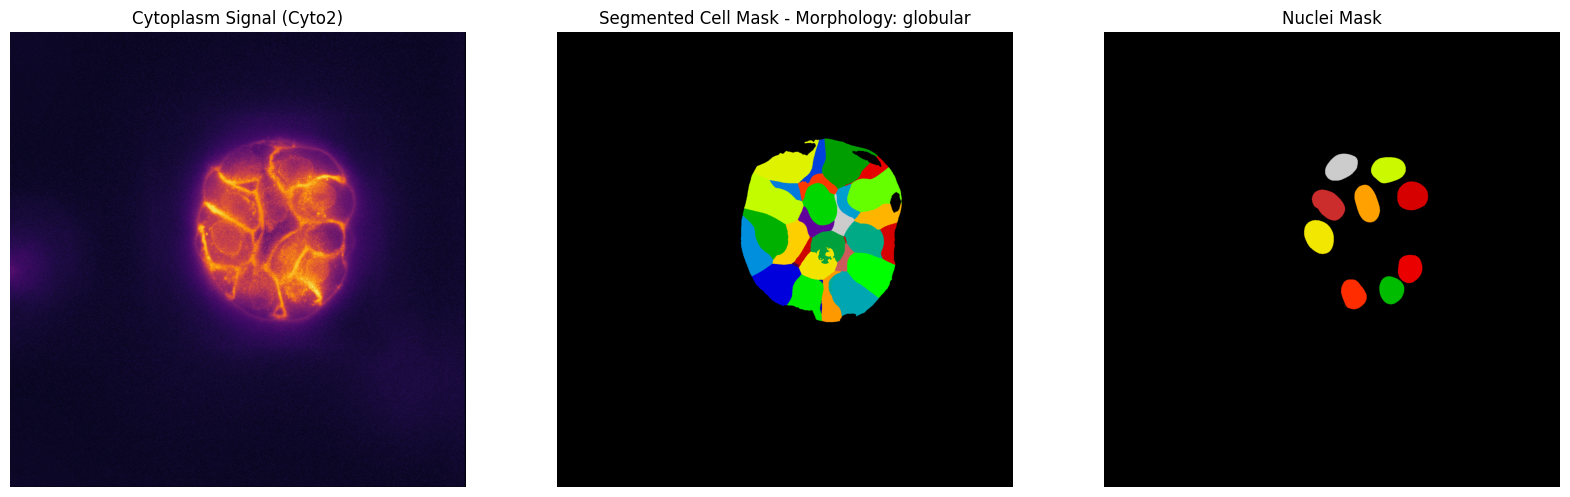

In [8]:
if in_notebook:
    plt.figure(figsize=(20, 20))
    plt.subplot(131)
    plt.imshow(cyto2[cyto2.shape[0] // 2], cmap="inferno")
    plt.title("Cytoplasm Signal (Cyto2)")
    plt.axis("off")
    plt.subplot(132)
    plt.imshow(cell_mask[cell_mask.shape[0] // 2], cmap="nipy_spectral")
    plt.title(f"Segmented Cell Mask - Morphology: {morphology_class}")
    plt.axis("off")
    plt.subplot(133)
    plt.imshow(nuclei_mask[nuclei_mask.shape[0] // 2], cmap="nipy_spectral")
    plt.title("Nuclei Mask")
    plt.axis("off")
    plt.show()

## run the mask reassignment function (post-hoc)
### This needs to occur after both nuclei and cell segmentations are done

In [9]:
cell_df = get_labels_for_post_hoc_reassignment(
    compartment_mask=cell_mask, compartment_name="cell"
)
nuclei_df = get_labels_for_post_hoc_reassignment(
    compartment_mask=nuclei_mask, compartment_name="nuclei"
)

In [10]:
nuclei_mask, reassigned_nuclei_df = run_post_hoc_mask_reassignment(
    nuclei_mask=nuclei_mask,
    cell_mask=cell_mask,
    nuclei_df=nuclei_df,
    cell_df=cell_df,
    return_dataframe=True,
)

In [11]:
# refine the cell masks
# run the post hoc refinement step to reassign nuclei and cell masks to be the same label
# if they are "connected" i.e. if the nucleus is within the cell mask, then assign the same label to the cell mask as the nucleus mask
cell_mask = run_post_hoc_refinement(
    mask_image=cell_mask,
    sliding_window_context=3,
)

## Cytoplasm Segmentation

In [12]:
cytoplasm_mask = create_cytoplasm_masks(
    nuclei_masks=nuclei_mask,
    cell_masks=cell_mask,
)

## Remove border objects

In [13]:
# nuclei should already have objects removed at the border from the previous notebook,
# but we can run this again just to be safe
nuclei_mask = clean_border_objects(nuclei_mask, border_width=5)
cell_mask = clean_border_objects(cell_mask, border_width=5)
cytoplasm_mask = clean_border_objects(cytoplasm_mask, border_width=5)

In [14]:
# since the nuclei - cell masks should be 1:1
# check if there are any singletons and remove those labels
unique_nuclei_labels = np.unique(nuclei_mask)
unique_cell_labels = np.unique(cell_mask)
unmatched_labels_to_remove = list(set(unique_nuclei_labels) - set(unique_cell_labels))


for label_id in unmatched_labels_to_remove:
    nuclei_mask = remove_label_id(nuclei_mask, label_id)
    cell_mask = remove_label_id(cell_mask, label_id)
    cytoplasm_mask = remove_label_id(cytoplasm_mask, label_id)

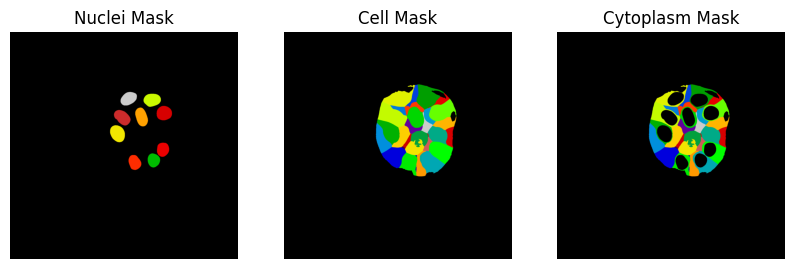

In [15]:
if in_notebook:
    z = cell_mask.shape[0] // 2
    plt.figure(figsize=(10, 10))
    plt.subplot(131)
    plt.title("Nuclei Mask")
    plt.imshow(nuclei_mask[z, :, :], cmap="nipy_spectral")
    plt.axis("off")
    plt.subplot(132)
    plt.title("Cell Mask")
    plt.imshow(cell_mask[z, :, :], cmap="nipy_spectral")
    plt.axis("off")
    plt.subplot(133)
    plt.title("Cytoplasm Mask")
    plt.imshow(cytoplasm_mask[z, :, :], cmap="nipy_spectral")
    plt.axis("off")
    plt.show()

## Save the segmented masks

In [16]:
nuclei_mask_output = pathlib.Path(f"{mask_path}/nuclei_mask.tiff")
cell_mask_output = pathlib.Path(f"{mask_path}/cell_mask.tiff")
cytoplasm_mask_output = pathlib.Path(f"{mask_path}/cytoplasm_mask.tiff")
tifffile.imwrite(nuclei_mask_output, nuclei_mask)
tifffile.imwrite(cell_mask_output, cell_mask)
tifffile.imwrite(cytoplasm_mask_output, cytoplasm_mask)

In [17]:
stop_profiling(
    start_time=start_time,
    start_mem=start_mem,
    feature_type="Segmentation",
    well_fov=well_fov,
    patient_id=patient,
    channel="NoChannel",
    compartment="cell",
    CPU_GPU="GPU",
    output_file_dir=pathlib.Path(
        f"{image_base_dir}/data/{patient}/segmentation_masks/run_stats/{well_fov}_cell_segmentation.parquet"
    ),
)


        Memory and time profiling for the run:
        Patient ID: NF0014_T1
        Well and FOV: D9-3
        Feature type: Segmentation
        CPU/GPU: GPU
        Peak memory (tracemalloc): 6924.59 MB
        Current memory (tracemalloc): 1662.18 MB
        RSS at end: 2919.68 MB
        Time elapsed:
        --- 1293.45 seconds ---
        --- 21.56 minutes ---
        --- 0.36 hours ---
    


True

Note for an image of the pixel size (20, 1500, 1500) (Z,Y,X). 
This runs in under 1 minute on a CPU and uses less than 1GB of RAM.

In [18]:
print(np.unique(nuclei_mask))
print(np.unique(cell_mask))
print(np.unique(cytoplasm_mask))

[   0  257  771 1028 1542 1799 2056 2313 2570 2827 3084 3341 3598 3855
 4112 4369 4626 4883 5140 5397 5654 5911 6168 6425 6682 6939 7196 7453
 7710 7967 8224 8481 8738 8995 9252 9509]
[   0  257  771 1028 1542 1799 2056 2313 2570 2827 3084 3341 3598 3855
 4112 4369 4626 4883 5140 5397 5654 5911 6168 6425 6682 6939 7196 7453
 7710 7967 8224 8481 8738 8995 9252 9509]
[   0  257  771 1028 1542 1799 2056 2313 2570 2827 3084 3341 3598 3855
 4112 4369 4626 4883 5140 5397 5654 5911 6168 6425 6682 6939 7196 7453
 7710 7967 8224 8481 8738 8995 9252 9509]
